In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": False,     
    "font.family": "serif",
    "mathtext.fontset": "cm", 
    #"font.size": 12,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2
})



In [5]:
import os

print(os.getcwd())

c:\Users\Julian Samuel\Documents\GitHub\Protuberance-Optimization\Codes


In [10]:
route_cam8 = "C:/Users/Julian Samuel/Documents/GitHub/Protuberance-Optimization/Datos_sim cam 8"

files = {}

for file in os.listdir(route_cam8):
    if file.endswith(".csv"):
        data = pd.read_csv(os.path.join(route_cam8, file), skiprows=4)
        files[file] = data
print(files.keys())

print(files["cp_1000_z.csv"].head())

dict_keys(['cp1000_y.csv', 'cp_1000.csv', 'cp_1000_z.csv', 'cp_cam_y.csv', 'Cp_cross.csv', 'cp_curve_cam.csv'])
    Z [ m ]  Pressure Coefficient
0  0.183960             -0.006008
1  0.187231             -0.003796
2  0.189652             -0.002870
3  0.190792             -0.004130
4  0.190811             -0.004169


74 74


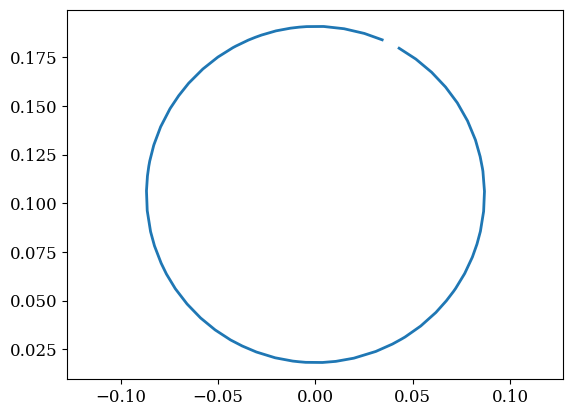

In [11]:
z = files["cp_1000_z.csv"]["Z [ m ]"]
y = files["cp1000_y.csv"]["Y [ m ]"]
print(len(z),len(y))
plt.figure()
plt.plot(y, z)
plt.axis('equal')
plt.show()

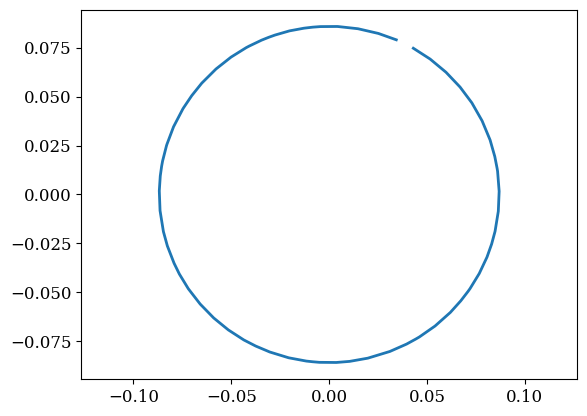

In [12]:
def rot_marix(pitch, roll):
    M_pitch = np.array([
        
        [np.cos(pitch), 0, -np.sin(pitch)],
        [0, 1, 0],
        [np.sin(pitch), 0, np.cos(pitch)]
        
        ])

    M_roll = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll), np.cos(roll)]
        ])
    return M_pitch @ M_roll



x = np.ones(len(z))*np.cos(np.radians(6)) 
r = list(zip(x, y, z))
r_shaped = r @ rot_marix(np.radians(6), np.radians(0))

plt.figure()
plt.plot(r_shaped[:, 1], r_shaped[:, 2])
plt.axis('equal')
plt.show()


In [13]:
ref = np.array([0, min(r_shaped[:, 2])])   # (y,z)

yz = r_shaped[:, 1:3]
cross = ref[0]*yz[:, 1] - ref[1]*yz[:, 0]
dot = ref[0]*yz[:, 0] + ref[1]*yz[:, 1]

theta = np.degrees(np.arctan2(cross, dot))

theta = np.mod(theta, 180)
theta

array([156.54470701, 163.00637031, 170.14302986, 177.0551147 ,
       177.3635128 ,   3.01850653,   5.57392863,   8.61425388,
        13.59636442,  13.67567907,  18.77701084,  21.11124198,
        23.63484861,  28.35374282,  29.49495612,  35.53699858,
        42.06505251,  48.87082744,  54.30333278,  59.30619859,
        59.7165041 ,  66.51185731,  66.5251533 ,  72.86863883,
        73.38476471,  78.64720048,  80.43939383,  83.75702521,
        88.7864703 ,  95.46954389, 102.63812905, 107.63039156,
       113.90102054, 117.9869901 , 123.80628199, 130.33365789,
       136.92301107, 143.33616429, 149.55489066, 149.71028943,
       154.12089891, 159.34628877, 166.06895175, 172.19688524,
       174.35075512, 176.65061486,   2.40431937,   7.00226404,
        13.2661288 ,  21.13349537,  27.33711406,  30.94491032,
        32.32683857,  38.81561437,  45.75940282,  51.05481567,
        55.02235921,  56.25483592,  62.20960457,  68.34343544,
        73.02350896,  77.46722487,  84.29678635,  91.05

In [14]:
data_shaped = pd.DataFrame({
    "theta": theta,
    "Cp": files["cp_1000_z.csv"]["Pressure Coefficient"],
    "y": r_shaped[:, 1],
    "z": r_shaped[:, 2]
})
data_shaped




,theta,Cp,y,z
0,156.544707,-0.006008,0.034275,0.078996
1,163.006370,-0.003796,0.025136,0.082250
2,170.143030,-0.002870,0.014710,0.084657
3,177.055115,-0.004130,0.004413,0.085791
4,177.363513,-0.004169,0.003951,0.085810
...,...,...,...,...
69,122.708421,-0.016728,0.072880,0.046803
70,129.392090,-0.028034,0.066833,0.054882
71,136.282863,-0.024823,0.059683,0.062418
72,143.289445,-0.014911,0.051571,0.069161


In [15]:
starboard = data_shaped[y >= 0]
port = data_shaped[y < 0]
starboard = starboard.sort_values("theta")


port = port.sort_values("theta")
port["theta"] = np.abs(port["theta"] -180)

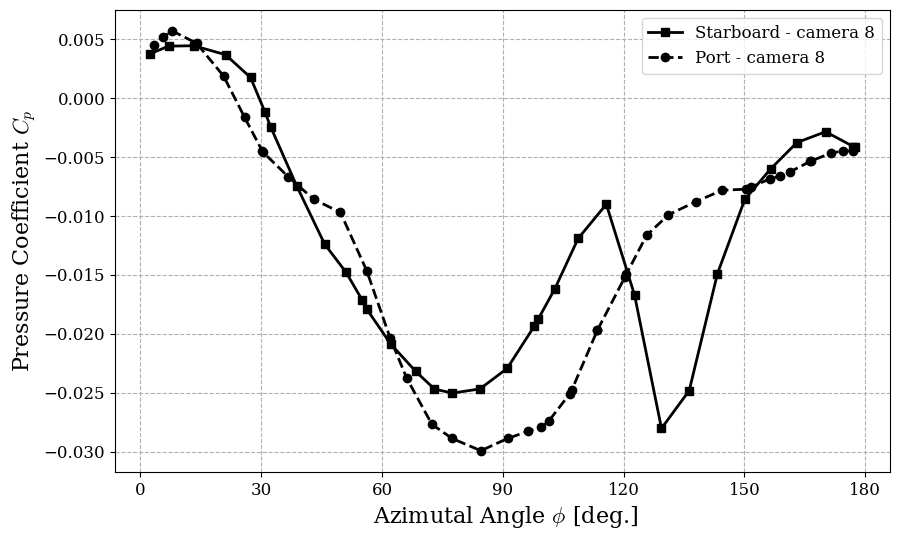

In [17]:
plt.figure(figsize=(10, 6))
#plt.scatter(theta_pos["theta"], theta_pos["Cp"], label="Cp cam 8 upper")
#plt.scatter(theta_neg["theta"], theta_neg["Cp"], label="Cp cam 8 lower")
plt.plot(starboard["theta"], starboard["Cp"], marker = "s", label="Starboard - camera 8", color = "k")
plt.plot(port["theta"], port["Cp"], marker = "o", label="Port - camera 8", color = "k", linestyle = "--")
plt.xlabel(" Azimutal Angle $\\phi$ [deg.]")
plt.ylabel("Pressure Coefficient $C_p$")
#plt.title(" vs")
plt.xticks(np.arange(0,181, 30))
plt.grid(linestyle='--')
plt.legend()
plt.show()